# 02 — Training Monitoring

Visualise training dynamics from saved checkpoint metadata:
- Loss and AUROC / F1 curves (train / val)
- Early stopping behaviour per run

**All** runs found under `CHECKPOINT_DIR` are loaded individually (no overwriting).  
When `results/{task}/data_efficiency/results_per_seed.csv` is present, run names are
automatically enriched with the matching subset ratio and seed.

Use the **run selector** in Section 1 to focus on a subset before plotting.

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [18]:
# ── Task ──────────────────────────────────────────────────────────────────────
# Used to locate the matching results_per_seed.csv for run-name enrichment.
TASK = "ulcer"  # "ulcer" | "mes"

# ── Checkpoint directory ───────────────────────────────────────────────────────
# All history.json files found recursively under this folder are loaded.
CHECKPOINT_DIR = ROOT / "output" / TASK / "models"

# Or point directly at a single history.json (overrides CHECKPOINT_DIR):
HISTORY_JSON = None  # e.g. Path("output/.../history.json")

## 1. Load & Select Runs

In [19]:
def find_history_files(root: Path) -> list[Path]:
    """Recursively find all history.json files under root."""
    return sorted(root.glob("**/history.json")) if root.exists() else []


def load_history(json_path: Path) -> pd.DataFrame:
    with open(json_path) as f:
        data = json.load(f)
    return pd.DataFrame(data)


# ── Optional enrichment: seed & subset ratio from results_per_seed.csv ────────
# Maps checkpoint timestamp → (seed, pct_data)
_SEED_LOOKUP: dict[str, tuple[int, int]] = {}
_perseed_path = ROOT / "results" / TASK / "data_efficiency" / "results_per_seed.csv"
if _perseed_path.exists():
    _ps = pd.read_csv(_perseed_path)
    if "checkpoint_dir" in _ps.columns:
        for _, _row in _ps.iterrows():
            _ts = Path(str(_row["checkpoint_dir"])).name
            _SEED_LOOKUP[_ts] = (int(_row["seed"]), int(_row["pct_data"]))
    print(f"Seed/subset lookup: {len(_SEED_LOOKUP)} entries from {_perseed_path.name}")
else:
    print(f"No results_per_seed.csv found at {_perseed_path} — run names will include timestamps.")

# ── Load all runs (each kept separately, no overwriting) ──────────────────────
if HISTORY_JSON:
    histories: dict[str, pd.DataFrame] = {
        Path(HISTORY_JSON).parent.name: load_history(HISTORY_JSON)
    }
else:
    found = find_history_files(CHECKPOINT_DIR)
    print(f"Found {len(found)} history file(s) under {CHECKPOINT_DIR}")
    histories = {}
    for p in found:
        # Path: .../models/[model]/[freeze]/[head]/[timestamp]/history.json
        model_name = p.parts[-5]
        freeze     = p.parts[-4]
        head       = p.parts[-3]
        ts         = p.parts[-2]

        if ts in _SEED_LOOKUP:
            seed, pct = _SEED_LOOKUP[ts]
            run_name = f"{model_name} | {pct}% | seed={seed} | {head}"
        else:
            run_name = f"{model_name}/{freeze}/{head}/{ts}"

        # Append counter on the rare collision
        _base, _n = run_name, 1
        while run_name in histories:
            run_name = f"{_base} [{_n}]"
            _n += 1

        try:
            histories[run_name] = load_history(p)
        except Exception as e:
            print(f"  Could not load {p}: {e}")

if not histories:
    print(
        "\n  No training history found yet.\n"
        "  Run at least one training job first:\n"
        "\n"
        "    python -m scripts.ulcer.run_data_efficiency --subset-ratios 0.1 --seeds 42 --epochs 5\n"
        "    python -m scripts.mes.run_data_efficiency   --subset-ratios 0.1 --seeds 42 --epochs 5\n"
        "\n"
        "  Then update CHECKPOINT_DIR / TASK above."
    )
else:
    print(f"Loaded {len(histories)} run(s)")
    sample = next(iter(histories.values()))
    print(f"Columns: {list(sample.columns)}")
    display(sample.head(3))

Seed/subset lookup: 210 entries from results_per_seed.csv
Found 210 history file(s) under ../output/ulcer/models
Loaded 210 run(s)
Columns: ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1', 'val_auroc', 'lr', 'is_best']


,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_auroc,lr,is_best
0,1,0.882830,0.362069,0.907278,0.446154,0.543779,0.497805,3.000000e-08,True
1,2,0.882163,0.365517,0.890063,0.486713,0.587177,0.562440,6.024000e-06,True
2,3,0.869194,0.351724,0.874843,0.523077,0.607595,0.628829,1.201800e-05,True


In [20]:
# ── Run selector ──────────────────────────────────────────────────────────────
# With ipywidgets: use the multi-select widget below (Ctrl/Shift+click).
# Without ipywidgets: set SELECTED_RUNS to a list of names, or None for all.
SELECTED_RUNS: list[str] | None = None

try:
    import ipywidgets as widgets
    from IPython.display import display as _disp

    _sel = widgets.SelectMultiple(
        options=sorted(histories.keys()),
        value=sorted(histories.keys()),
        layout=widgets.Layout(width="90%", height="200px"),
    )
    _disp(widgets.VBox([
        widgets.Label(
            f"Select runs to plot — {len(histories)} loaded "
            "(Ctrl+click / Shift+click for multi-select):"
        ),
        _sel,
    ]))

    def get_selected() -> dict[str, pd.DataFrame]:
        chosen = list(_sel.value) or sorted(histories.keys())
        return {k: histories[k] for k in chosen if k in histories}

except ImportError:
    def get_selected() -> dict[str, pd.DataFrame]:  # type: ignore[misc]
        if SELECTED_RUNS:
            return {k: histories[k] for k in SELECTED_RUNS if k in histories}
        return dict(histories)

    print(f"ipywidgets not available — all {len(histories)} runs shown.")
    print("Set SELECTED_RUNS = ['name1', ...] to filter.\n")
    print("Available runs:")
    for name in sorted(histories):
        print(f"  · {name}")

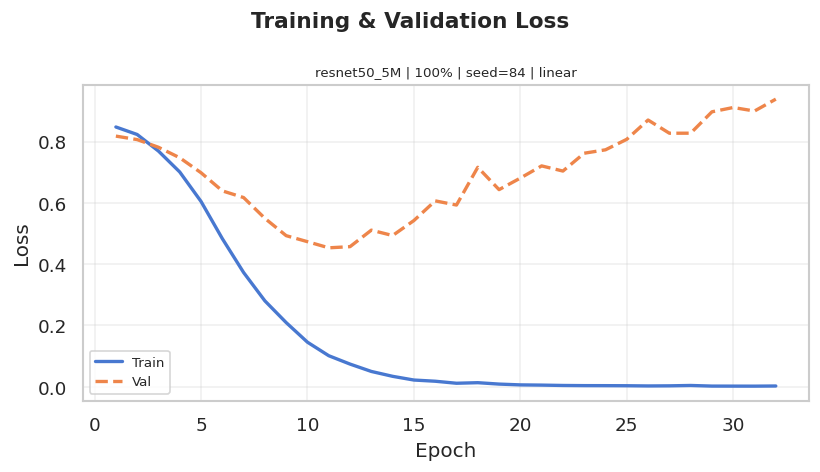

In [29]:
def plot_loss_curves(histories: dict[str, pd.DataFrame]) -> None:
    items = list(histories.items())
    n = len(items)
    if n == 0:
        print("No histories to plot.")
        return

    ncols = min(n, 2)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)
    fig.suptitle("Training & Validation Loss", fontsize=13, fontweight="bold")

    for idx, (name, df) in enumerate(items):
        ax = axes[idx // ncols][idx % ncols]
        x = df["epoch"] if "epoch" in df else range(len(df))
        if "train_loss" in df.columns:
            ax.plot(x, df["train_loss"], label="Train", linewidth=2)
        if "val_loss" in df.columns:
            ax.plot(x, df["val_loss"], label="Val", linewidth=2, linestyle="--")
        ax.set_title(name, fontsize=8)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_loss_curves(get_selected())

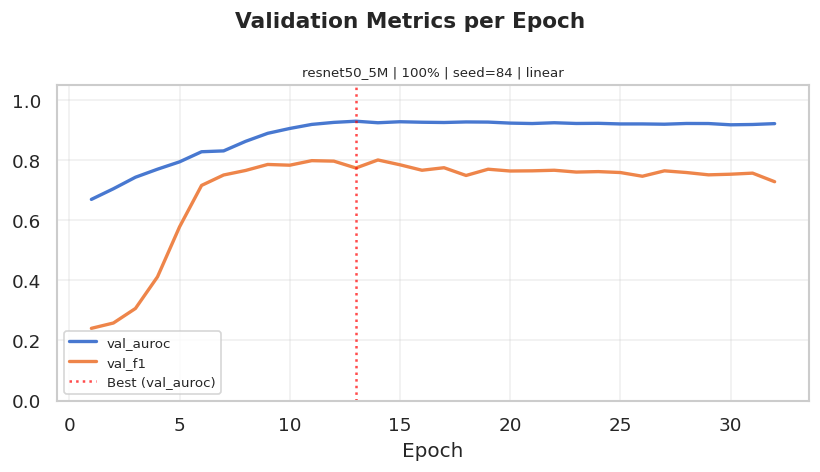

In [31]:
def plot_metric_curves(
    histories: dict[str, pd.DataFrame],
    metrics: list[str] = ("val_auroc", "val_f1"),
) -> None:
    items = list(histories.items())
    n = len(items)
    if n == 0:
        return

    ncols = min(n, 2)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)
    fig.suptitle("Validation Metrics per Epoch", fontsize=13, fontweight="bold")

    for idx, (name, df) in enumerate(items):
        ax = axes[idx // ncols][idx % ncols]
        x = df["epoch"] if "epoch" in df else range(len(df))
        for metric in metrics:
            if metric in df.columns:
                ax.plot(x, df[metric], label=metric, linewidth=2)
        best_col = "val_auroc" if "val_auroc" in df.columns else (metrics[0] if metrics[0] in df.columns else None)
        if best_col:
            best_idx = df[best_col].idxmax()
            bx = df.loc[best_idx, "epoch"] if "epoch" in df.columns else best_idx
            ax.axvline(x=bx, color="red", linestyle=":", alpha=0.7, label=f"Best ({best_col})")
        ax.set_title(name, fontsize=8)
        ax.set_xlabel("Epoch")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_metric_curves(get_selected())

In [33]:
def compare_best_metrics(histories: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Extract the best-epoch metrics from each run."""
    rows = []
    for name, df in histories.items():
        best_col = next((c for c in ("val_auroc", "val_f1") if c in df.columns), None)
        if best_col is None:
            continue
        best_row = df.loc[df[best_col].idxmax()].to_dict()
        best_row["run"] = name
        rows.append(best_row)
    return pd.DataFrame(rows).set_index("run") if rows else pd.DataFrame()

best_df = compare_best_metrics(get_selected())
if not best_df.empty:
    metric_cols = [c for c in best_df.columns if any(m in c for m in ("auroc", "f1", "loss"))]
    display(best_df[metric_cols].round(4).sort_values(
        [c for c in ("val_auroc", "val_f1") if c in metric_cols][:1], ascending=False
    ))

,train_loss,val_loss,val_f1,val_auroc
run,,,,
resnet50_5M | 100% | seed=84 | linear,0.0498,0.5108,0.7733,0.9289


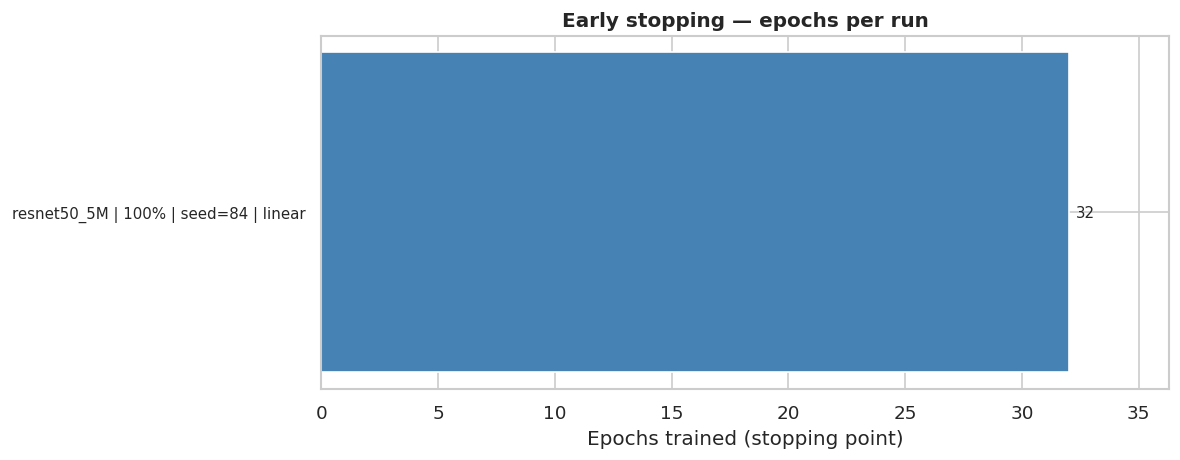

In [35]:
def plot_stopping_epochs(histories: dict[str, pd.DataFrame]) -> None:
    if not histories:
        return

    names = list(histories.keys())
    n_epochs = [len(df) for df in histories.values()]

    fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 0.5)))
    bars = ax.barh(names, n_epochs, color="steelblue")
    for bar, n in zip(bars, n_epochs):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(n), va="center", fontsize=9)
    ax.set_xlabel("Epochs trained (stopping point)")
    ax.set_title("Early stopping — epochs per run", fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.08)
    fig.tight_layout()
    plt.show()

plot_stopping_epochs(get_selected())